In [2]:
from typing import List, Literal, TypedDict
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_huggingface import HuggingFaceEndpoint
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import List
from langchain_community.tools.tavily_search import TavilySearchResults
load_dotenv()


True

In [3]:
docs = (
     PyPDFLoader("./Books/book1.pdf").load()
)


In [4]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)


In [5]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3325.92it/s]


KeyboardInterrupt: 

In [6]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0,
)


In [7]:
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    answer: str


In [8]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with exactly one boolean field named should_retrieve.\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)
def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}
#


In [9]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)
def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [10]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}


In [11]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"


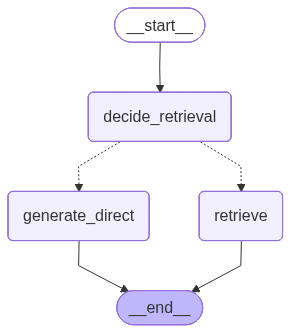

In [12]:
g = StateGraph(State)
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_edge(START, "decide_retrieval")
g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)
g.add_edge("generate_direct", END)
g.add_edge("retrieve", END)
app = g.compile()
app


In [13]:
result = app.invoke(
    {
        "question": "What is Machine Learning",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)
print(result["answer"])


Machine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to learn from data, make decisions, and improve their performance over time without being explicitly programmed.

In traditional programming, a computer is given a set of instructions to follow in order to perform a specific task. In contrast, machine learning allows a computer to learn from experience and adapt to new situations by analyzing data and identifying patterns.

There are several key characteristics of machine learning:

1. **Learning from data**: Machine learning algorithms use data to learn and improve their performance.
2. **Improvement over time**: As more data is available, machine learning models can improve their accuracy and performance.
3. **Autonomy**: Machine learning models can make decisions and take actions without human intervention.
4. **Flexibility**: Machine learning models can be applied to a wide range of tasks, inclu

In [14]:
result['need_retrieval']


False

In [15]:
result['docs']


[]